In [17]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
from matplotlib import pyplot
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [18]:
# Configure the matplotlib figure style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
pyplot.rcParams.update(RC)

In [19]:
# Load envelope TRFs for all subjects
trfs = []
r_values = []
proportion_explained_values = []

SUBJECTS = helper_functions.get_subjects()

for subject in SUBJECTS:
    # unpadded trials
    attended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_trf.pickle'
    unattended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_trf.pickle'

    # padded trials
    attended_padded_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_padded_trf.pickle'
    unattended_padded_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_padded_trf.pickle'

    # envelope + onset
    attended_envelope_onset_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_envelope_onset_trf.pickle'
    unattended_envelope_onset_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_envelope_onset_trf.pickle'


    if attended_trf_path.exists() and unattended_trf_path.exists() and attended_padded_trf_path.exists() and unattended_padded_trf_path.exists() and attended_envelope_onset_trf_path.exists() and unattended_envelope_onset_trf_path.exists():
        # Load both unpadded and padded TRFs for the subject
        trf_attended = eelbrain.load.unpickle(attended_trf_path)
        trf_unattended = eelbrain.load.unpickle(unattended_trf_path)

        trf_attended_padded = eelbrain.load.unpickle(attended_padded_trf_path)
        trf_unattended_padded = eelbrain.load.unpickle(unattended_padded_trf_path)

        trf_attended_onset = eelbrain.load.unpickle(attended_envelope_onset_trf_path)
        trf_unattended_onset = eelbrain.load.unpickle(unattended_envelope_onset_trf_path)

        trfs.append((trf_attended, trf_unattended, trf_attended_padded, trf_unattended_padded, trf_attended_onset, trf_unattended_onset))
        
        r_values.append((trf_attended.r, trf_unattended.r, trf_attended_padded.r, trf_unattended_padded.r, trf_attended_onset.r, trf_unattended_onset.r))
        proportion_explained_values.append((trf_attended.proportion_explained, trf_unattended.proportion_explained, trf_attended_padded.proportion_explained, trf_unattended_padded.proportion_explained, trf_attended_onset.proportion_explained, trf_unattended_onset.proportion_explained))

        # Note that r does not take into account the model’s ability to predict the magnitude of the response, only its shape; for a measure that reflects both, consider using proportion_explained.

        print(f"Loaded TRFs for {subject}")
    else:
        print(f"TRF files for {subject} not found, skipping.")
        

print(f"Loaded TRFs for {len(trfs)} subjects")

Loaded TRFs for S1
Loaded TRFs for S2
Loaded TRFs for S3
Loaded TRFs for S4
Loaded TRFs for S5
Loaded TRFs for S6
Loaded TRFs for S7
Loaded TRFs for S8
Loaded TRFs for S9
Loaded TRFs for S10
Loaded TRFs for S11
Loaded TRFs for S12
Loaded TRFs for S13
Loaded TRFs for S14
Loaded TRFs for S15
Loaded TRFs for S16
Loaded TRFs for S17
Loaded TRFs for S18
Loaded TRFs for 18 subjects


# Compare attended and unsattended TRFs

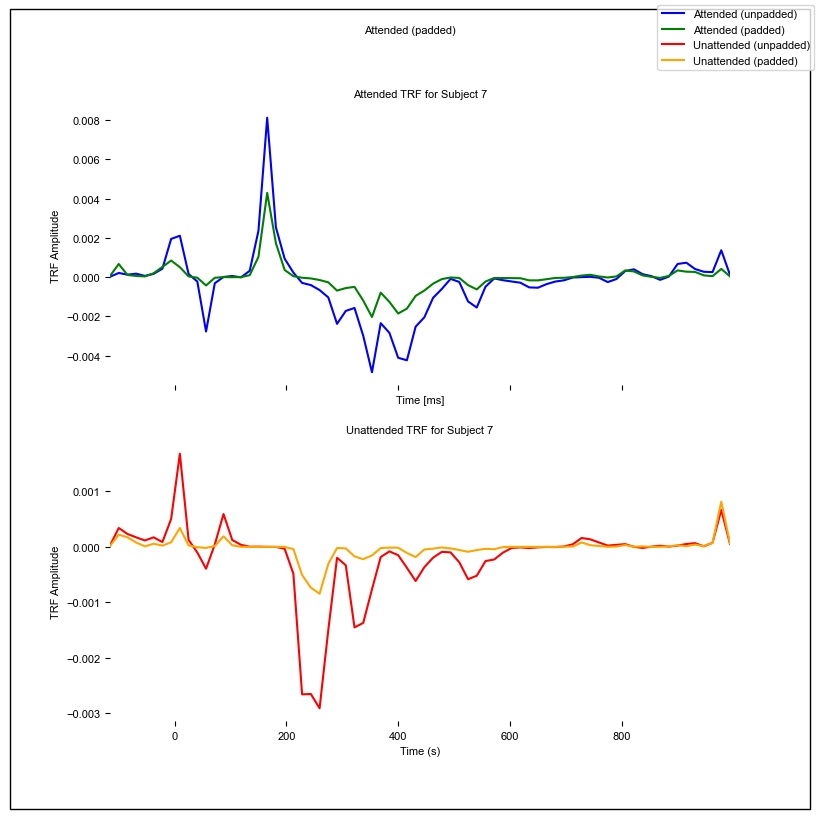

In [20]:
SUBJECT_NUMBER = 7

attended_trf_mean = trfs[SUBJECT_NUMBER -1 ][0].h.mean('sensor')
unattended_trf_mean = trfs[SUBJECT_NUMBER - 1][1].h.mean('sensor')

attended_padded_trf_mean = trfs[SUBJECT_NUMBER -1 ][2].h.mean('sensor')
unattended_padded_trf_mean = trfs[SUBJECT_NUMBER - 1][3].h.mean('sensor')

# plot the TRFs together in one plot for the first subject with pyplot
# Setup the figure layout
fig, axes = pyplot.subplots(2, figsize=(8, 8), sharex=True, subplot_kw=dict(frame_on=False))
eelbrain.plot.UTS(attended_trf_mean, axes=axes[0], color='blue', title='Attended (unpadded)')
eelbrain.plot.UTS(attended_padded_trf_mean, axes=axes[0], color='green', title='Attended (padded)')

eelbrain.plot.UTS(unattended_trf_mean, axes=axes[1], color='red')
eelbrain.plot.UTS(unattended_padded_trf_mean, axes=axes[1], color='orange')

# compute sensible y-limits from the plotted curves
ymin = min(attended_trf_mean.x.min(), attended_padded_trf_mean.x.min())
ymax = max(attended_trf_mean.x.max(), attended_padded_trf_mean.x.max())
margin = 0.05 * (ymax - ymin)
axes[0].set_ylim(ymin - margin, ymax + margin)
ymin = min(unattended_trf_mean.x.min(), unattended_padded_trf_mean.x.min())
ymax = max(unattended_trf_mean.x.max(), unattended_padded_trf_mean.x.max())
margin = 0.05 * (ymax - ymin)
axes[1].set_ylim(ymin - margin, ymax + margin)


#fig.legend(['Attended', 'Unattended', ], loc='upper right')
fig.legend(['Attended (unpadded)', 'Attended (padded)', 'Unattended (unpadded)', 'Unattended (padded)'], loc='upper right')
axes[0].set_title(f'Attended TRF for Subject {SUBJECT_NUMBER}')
axes[1].set_title(f'Unattended TRF for Subject {SUBJECT_NUMBER}')
axes[0].set_ylabel('TRF Amplitude')

axes[1].set_ylabel('TRF Amplitude')
axes[1].set_xlabel('Time (s)')


eelbrain.plot.figure_outline()
fig.savefig(file_paths.FIGURES_DIR / 'comparison_attended_unattended.png', bbox_inches='tight')

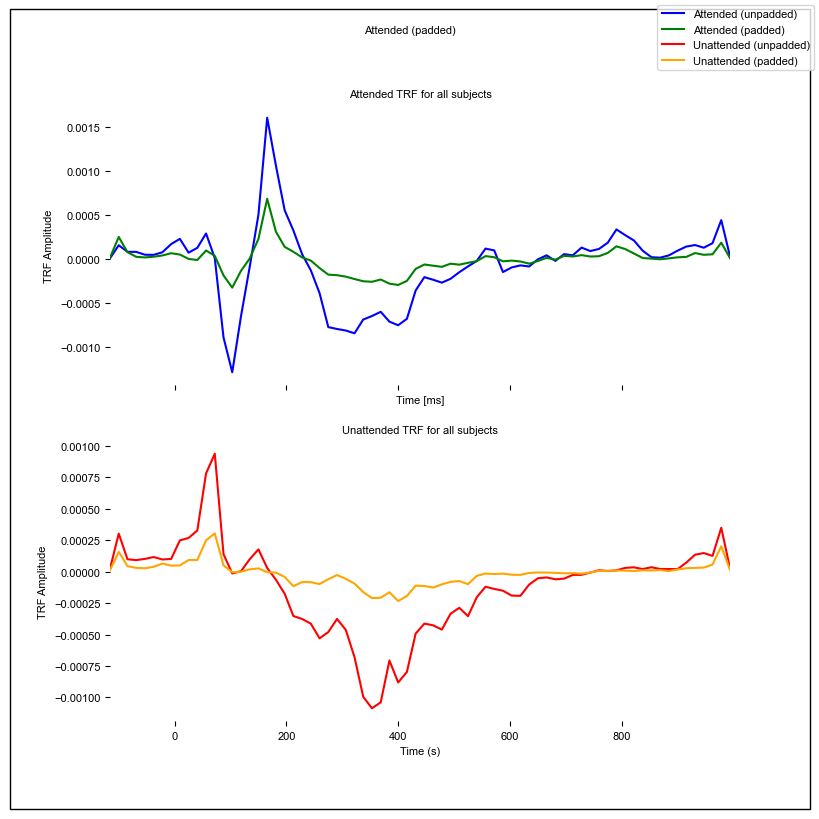

In [21]:
attended_trf_means = [trf[0].h.mean('sensor') for trf in trfs]
unattended_trf_means = [trf[1].h.mean('sensor') for trf in trfs]

attended_padded_trf_means = [trf[2].h.mean('sensor') for trf in trfs]
unattended_padded_trf_means = [trf[3].h.mean('sensor') for trf in trfs]

grand_attended_mean = eelbrain.combine(attended_trf_means).mean('case')
grand_unattended_mean = eelbrain.combine(unattended_trf_means).mean('case')

grand_attended_padded_mean = eelbrain.combine(attended_padded_trf_means).mean('case')
grand_unattended_padded_mean = eelbrain.combine(unattended_padded_trf_means).mean('case')

# plot the TRFs together in one plot for the first subject with pyplot
# Setup the figure layout
fig, axes = pyplot.subplots(2, figsize=(8, 8), sharex=True, subplot_kw=dict(frame_on=False))
eelbrain.plot.UTS(grand_attended_mean, axes=axes[0], color='blue', title='Attended (unpadded)')
eelbrain.plot.UTS(grand_attended_padded_mean, axes=axes[0], color='green', title='Attended (padded)')

eelbrain.plot.UTS(grand_unattended_mean, axes=axes[1], color='red')
eelbrain.plot.UTS(grand_unattended_padded_mean, axes=axes[1], color='orange')

# compute sensible y-limits from the plotted curves
ymin = min(grand_attended_mean.x.min(), grand_attended_padded_mean.x.min())
ymax = max(grand_attended_mean.x.max(), grand_attended_padded_mean.x.max())
margin = 0.05 * (ymax - ymin)
axes[0].set_ylim(ymin - margin, ymax + margin)
ymin = min(grand_unattended_mean.x.min(), grand_unattended_padded_mean.x.min())
ymax = max(grand_unattended_mean.x.max(), grand_unattended_padded_mean.x.max())
margin = 0.05 * (ymax - ymin)
axes[1].set_ylim(ymin - margin, ymax + margin)


#fig.legend(['Attended', 'Unattended', ], loc='upper right')
fig.legend(['Attended (unpadded)', 'Attended (padded)', 'Unattended (unpadded)', 'Unattended (padded)'], loc='upper right')
axes[0].set_title(f'Attended TRF for all subjects')
axes[1].set_title(f'Unattended TRF for all subjects')
axes[0].set_ylabel('TRF Amplitude')

axes[1].set_ylabel('TRF Amplitude')
axes[1].set_xlabel('Time (s)')


eelbrain.plot.figure_outline()
fig.savefig(file_paths.FIGURES_DIR / 'comparison_attended_unattended.png', bbox_inches='tight')

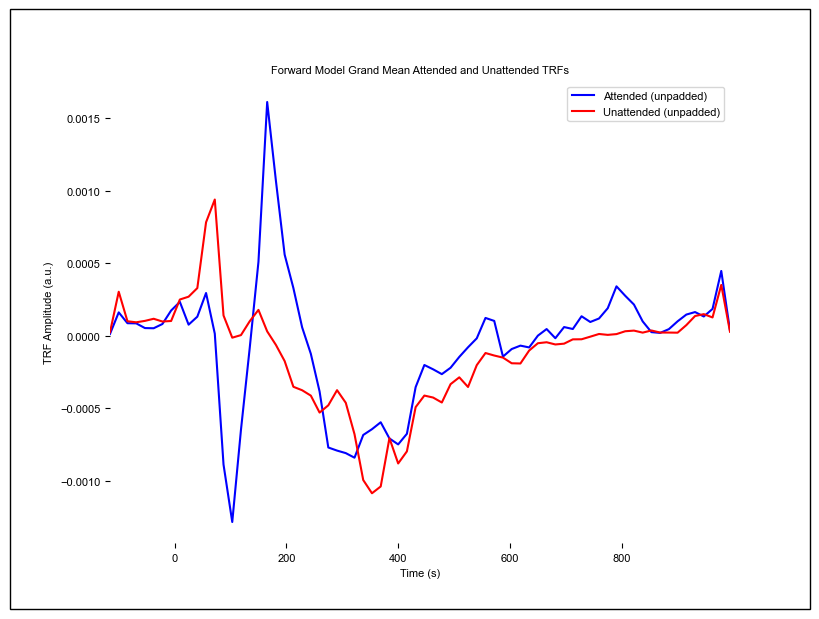

In [22]:
attended_trf_means = [trf[0].h.mean('sensor') for trf in trfs]
unattended_trf_means = [trf[1].h.mean('sensor') for trf in trfs]

# Compute grand mean TRFs across all subjects for attended and unattended (unpadded)
grand_attended_mean = eelbrain.combine(attended_trf_means).mean('case')
grand_unattended_mean = eelbrain.combine(unattended_trf_means).mean('case')

# Plot the grand mean TRFs overlaid in one plot
fig, ax = pyplot.subplots(1, figsize=(8, 6), subplot_kw=dict(frame_on=False))

eelbrain.plot.UTS(grand_attended_mean, axes=ax, color='blue')
eelbrain.plot.UTS(grand_unattended_mean, axes=ax, color='red')

# Compute sensible y-limits from the plotted curves
ymin = min(grand_attended_mean.x.min(), grand_unattended_mean.x.min())
ymax = max(grand_attended_mean.x.max(), grand_unattended_mean.x.max())
margin = 0.05 * (ymax - ymin)
ax.set_ylim(ymin - margin, ymax + margin)

# Legend
ax.legend(['Attended (unpadded)', 'Unattended (unpadded)'], loc='upper right')

ax.set_title('Forward Model Grand Mean Attended and Unattended TRFs')
ax.set_ylabel('TRF Amplitude (a.u.)')
ax.set_xlabel('Time (s)')

eelbrain.plot.figure_outline()
fig.savefig(file_paths.FIGURES_DIR / 'forward_model_trfs_comparison.png', bbox_inches='tight')

In [23]:
# Mean R values per subject for each condition
mean_attended_r_per_subject = [r_att.mean() for (r_att, _, _, _, _, _) in r_values]
mean_unattended_r_per_subject = [r_unatt.mean() for (_, r_unatt, _, _, _, _) in r_values]
mean_attended_padded_r_per_subject = [r_att_pad.mean() for (_, _, r_att_pad, _, _, _) in r_values]
mean_unattended_padded_r_per_subject = [r_unatt_pad.mean() for (_, _, _, r_unatt_pad, _, _) in r_values]
mean_attended_onset_r_per_subject = [r_att_ons.mean() for (_, _, _, _, r_att_ons, _) in r_values]
mean_unattended_onset_r_per_subject = [r_unatt_ons.mean() for (_, _, _, _, _, r_unatt_ons) in r_values]

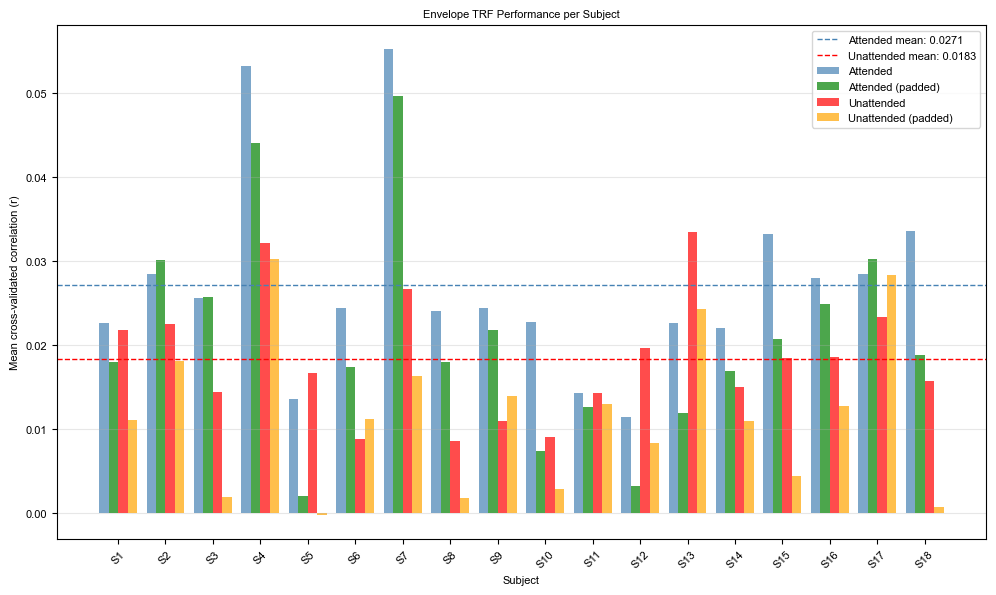

In [24]:
# Single plot of TRF performance per subject.
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(mean_attended_r_per_subject))
width = 0.2

# Attended bars
ax.bar(x - 1.5*width, mean_attended_r_per_subject, width,
       color='steelblue', alpha=0.7, label='Attended')
ax.bar(x - 0.5*width, mean_attended_padded_r_per_subject, width,
       color='green', alpha=0.7, label='Attended (padded)')

# Unattended bars
ax.bar(x + 0.5*width, mean_unattended_r_per_subject, width,
       color='red', alpha=0.7, label='Unattended')
ax.bar(x + 1.5*width, mean_unattended_padded_r_per_subject, width,
       color='orange', alpha=0.7, label='Unattended (padded)')

# Grand means
ax.axhline(np.mean(mean_attended_r_per_subject),
           color='steelblue', linestyle='--', linewidth=1,
           label=f'Attended mean: {np.mean(mean_attended_r_per_subject):.4f}')

ax.axhline(np.mean(mean_unattended_r_per_subject),
           color='red', linestyle='--', linewidth=1,
           label=f'Unattended mean: {np.mean(mean_unattended_r_per_subject):.4f}')

ax.set_xlabel('Subject')
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Envelope TRF Performance per Subject')

ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(len(mean_attended_r_per_subject))],
                   rotation=45)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig(file_paths.FIGURES_DIR / 'comparison_attended_unattended_summary.png', bbox_inches='tight')

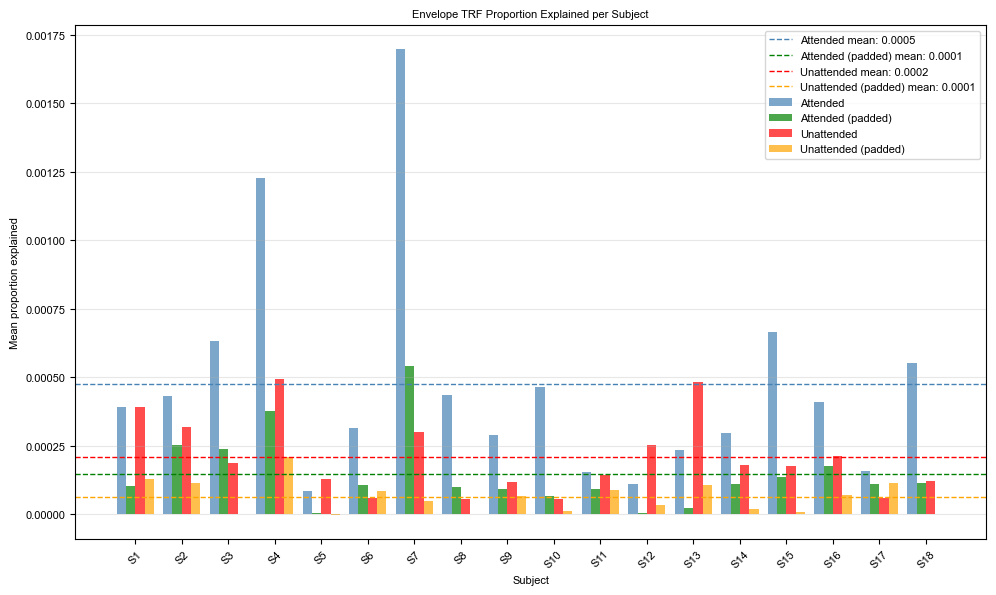

In [25]:
# ...existing code...
# Mean Proportion Explained values per subject for each condition
mean_attended_proportion_explained_per_subject = [pe_att.mean() for (pe_att, _, _, _, _, _) in proportion_explained_values]
mean_unattended_proportion_explained_per_subject = [pe_unatt.mean() for (_, pe_unatt, _, _, _, _) in proportion_explained_values]
mean_attended_padded_proportion_explained_per_subject = [pe_att_pad.mean() for (_, _, pe_att_pad, _, _, _) in proportion_explained_values]
mean_unattended_padded_proportion_explained_per_subject = [pe_unatt_pad.mean() for (_, _, _, pe_unatt_pad, _, _) in proportion_explained_values]


# Single plot of TRF performance per subject (proportion explained).
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(mean_attended_proportion_explained_per_subject))
width = 0.2

# Attended bars
ax.bar(x - 1.5*width, mean_attended_proportion_explained_per_subject, width,
       color='steelblue', alpha=0.7, label='Attended')
ax.bar(x - 0.5*width, mean_attended_padded_proportion_explained_per_subject, width,
       color='green', alpha=0.7, label='Attended (padded)')

# Unattended bars
ax.bar(x + 0.5*width, mean_unattended_proportion_explained_per_subject, width,
       color='red', alpha=0.7, label='Unattended')
ax.bar(x + 1.5*width, mean_unattended_padded_proportion_explained_per_subject, width,
       color='orange', alpha=0.7, label='Unattended (padded)')

# Grand means
ax.axhline(np.mean(mean_attended_proportion_explained_per_subject),
           color='steelblue', linestyle='--', linewidth=1,
           label=f'Attended mean: {np.mean(mean_attended_proportion_explained_per_subject):.4f}')
ax.axhline(np.mean(mean_attended_padded_proportion_explained_per_subject),
           color='green', linestyle='--', linewidth=1,
           label=f'Attended (padded) mean: {np.mean(mean_attended_padded_proportion_explained_per_subject):.4f}')
ax.axhline(np.mean(mean_unattended_proportion_explained_per_subject),
           color='red', linestyle='--', linewidth=1,
           label=f'Unattended mean: {np.mean(mean_unattended_proportion_explained_per_subject):.4f}')
ax.axhline(np.mean(mean_unattended_padded_proportion_explained_per_subject),
           color='orange', linestyle='--', linewidth=1,
           label=f'Unattended (padded) mean: {np.mean(mean_unattended_padded_proportion_explained_per_subject):.4f}')

ax.set_xlabel('Subject')
ax.set_ylabel('Mean proportion explained')
ax.set_title('Envelope TRF Proportion Explained per Subject')

ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(len(mean_attended_proportion_explained_per_subject))],
                   rotation=45)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig(file_paths.FIGURES_DIR / 'comparison_attended_unattended_summary_proportion_explained.png', bbox_inches='tight')
# ...existing code...

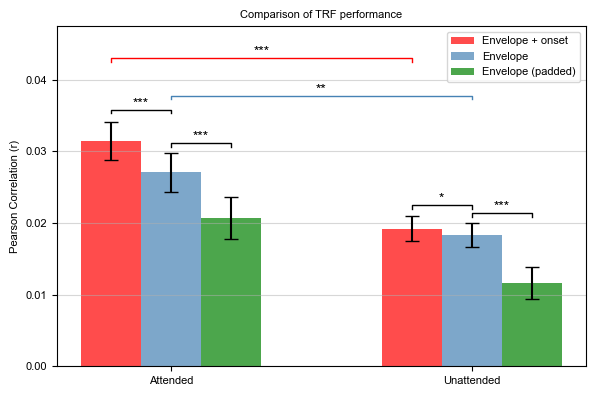

In [26]:
# show a grouped bar plot of the mean R values for each [attended, unattended] condition
# Show significance stars for the difference between padded and unpadded within each group
# and between attended and unattended within each padding condition

# Compute group means and standard errors
mean_vals = [np.mean(mean_attended_r_per_subject), np.mean(mean_unattended_r_per_subject)]
mean_vals_padded = [np.mean(mean_attended_padded_r_per_subject), np.mean(mean_unattended_padded_r_per_subject)]
mean_vals_onset = [np.mean(mean_attended_onset_r_per_subject), np.mean(mean_unattended_onset_r_per_subject)]

sem_vals = [np.std(mean_attended_r_per_subject, ddof=1) / np.sqrt(len(mean_attended_r_per_subject)),
            np.std(mean_unattended_r_per_subject, ddof=1) / np.sqrt(len(mean_unattended_r_per_subject))]
sem_vals_padded = [np.std(mean_attended_padded_r_per_subject, ddof=1) / np.sqrt(len(mean_attended_padded_r_per_subject)),
                   np.std(mean_unattended_padded_r_per_subject, ddof=1) / np.sqrt(len(mean_unattended_padded_r_per_subject))]
sem_vals_onset = [np.std(mean_attended_onset_r_per_subject, ddof=1) / np.sqrt(len(mean_attended_onset_r_per_subject)),
                   np.std(mean_unattended_onset_r_per_subject, ddof=1) / np.sqrt(len(mean_unattended_onset_r_per_subject))]

# Paired t-tests
attended_vs_padded_t, attended_vs_padded_p = stats.ttest_rel(mean_attended_r_per_subject, mean_attended_padded_r_per_subject)
unattended_vs_padded_t, unattended_vs_padded_p = stats.ttest_rel(mean_unattended_r_per_subject, mean_unattended_padded_r_per_subject)

attended_vs_onset_t, attended_vs_onset_p = stats.ttest_rel(mean_attended_r_per_subject, mean_attended_onset_r_per_subject)
unattended_vs_onset_t, unattended_vs_onset_p = stats.ttest_rel(mean_unattended_r_per_subject, mean_unattended_onset_r_per_subject)

attended_vs_unattended_t, attended_vs_unattended_p = stats.ttest_rel(mean_attended_r_per_subject, mean_unattended_r_per_subject)
attended_vs_unattended_onset_t, attended_vs_unattended_onset_p = stats.ttest_rel(mean_attended_onset_r_per_subject, mean_unattended_onset_r_per_subject)

def sig_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

sig_attended_vs_padded = sig_marker(attended_vs_padded_p)
sig_unattended_vs_padded = sig_marker(unattended_vs_padded_p)
sig_attended_vs_onset = sig_marker(attended_vs_onset_p)
sig_unattended_vs_onset = sig_marker(unattended_vs_onset_p)

sig_attended_vs_unattended = sig_marker(attended_vs_unattended_p)
sig_attended_vs_unattended_onset = sig_marker(attended_vs_unattended_onset_p)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(2)
width = 0.2

bars0 = ax.bar(x - width, mean_vals_onset, width, yerr=sem_vals, capsize=5,
               color='red', alpha=0.7, label='Envelope + onset')
bars1 = ax.bar(x, mean_vals, width, yerr=sem_vals, capsize=5,
               color='steelblue', alpha=0.7, label='Envelope')
bars2 = ax.bar(x + width, mean_vals_padded, width, yerr=sem_vals_padded, capsize=5,
               color='green', alpha=0.7, label='Envelope (padded)')

ax.set_xticks(x)
ax.set_xticklabels(['Attended', 'Unattended'])
ax.set_ylabel('Pearson Correlation (r)')
ax.set_title('Comparison of TRF performance')

# Add significance annotations

def add_sig_line(ax, x1, x2, y, text, color='k'):
    ax.plot([x1, x1, x2, x2], [y, y + 0.0005, y + 0.0005, y], color, linewidth=1)
    ax.text((x1 + x2) / 2, y + 0.0005, text, ha='center', va='bottom', fontsize=10)

# Determine max y for plotting significance bars
y_max = max(max(mean_vals + sem_vals), max(mean_vals_padded + sem_vals_padded))

# Within-group (padded vs unpadded) annotations
for xi, (m1, m2, sem1, sem2, sig) in enumerate(zip(mean_vals, mean_vals_padded, sem_vals, sem_vals_padded, [sig_attended_vs_padded, sig_unattended_vs_padded])):
    y = max(m1 + sem1, m2 + sem2) + 0.03 * y_max
    add_sig_line(ax, xi, xi + width, y, sig)

# Within-group envelope vs. onset annotations
for xi, (m1, m2, sem1, sem2, sig) in enumerate(zip(mean_vals, mean_vals_onset, sem_vals, sem_vals_onset, [sig_attended_vs_onset, sig_unattended_vs_onset])):
    y = max(m1 + sem1, m2 + sem2) + 0.035 * y_max
    add_sig_line(ax, xi - width, xi, y, sig)

# Between-group (unpadded attended vs unpadded unattended) annotation
# (compare the first and second unpadded bars)
y_between_unpadded = max(mean_vals[0] + sem_vals[0], mean_vals[1] + sem_vals[1]) + 0.275 * y_max
add_sig_line(ax, 0, 1, y_between_unpadded, sig_attended_vs_unattended, color="steelblue")

y_between_envelopes = max(mean_vals_onset[0] + sem_vals_onset[0], mean_vals_onset[1] + sem_vals_onset[1]) + 0.3 * y_max
add_sig_line(ax, 0 - width, 1 -width, y_between_envelopes, sig_attended_vs_unattended_onset, color="red")

ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.5)
ax.set_ylim(0, y_max * 1.75)

plt.tight_layout()
plt.show()
fig.savefig(file_paths.FIGURES_DIR / 'forward-model-bar-plot.png', bbox_inches='tight')

In [ ]:
# Print a LaTeX-formatted results summary using the computed mean and p-values
print("% Results summary (LaTeX)")
print()
print(r"\textbf{Mean correlation (r):}")
print(r"\begin{itemize}")
print(r"  \item Attended (envelope): $%.4f$" % np.mean(mean_attended_r_per_subject))
print(r"  \item Unattended (envelope): $%.4f$" % np.mean(mean_unattended_r_per_subject))
print(r"  \item Attended (padded): $%.4f$" % np.mean(mean_attended_padded_r_per_subject))
print(r"  \item Unattended (padded): $%.4f$" % np.mean(mean_unattended_padded_r_per_subject))
print(r"  \item Attended (envelope + onset): $%.4f$" % np.mean(mean_attended_onset_r_per_subject))
print(r"  \item Unattended (envelope + onset): $%.4f$" % np.mean(mean_unattended_onset_r_per_subject))
print(r"\end{itemize}")

print(" ")

# P-values for the comparisons
# attended_vs_padded_p
# unattended_vs_padded_p
# attended_vs_onset_p
# unattended_vs_onset_p
# attended_vs_unattended_p
# attended_vs_unattended_onset_p

print(r"\textbf{Statistical tests:}")
print(r"\begin{itemize}")
print(r"  \item Attended (envelope) vs. Unattended (envelope): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, attended_vs_unattended_t, attended_vs_unattended_p))
print(r"  \item Attended (envelope + onset) vs. Unattended (envelope + onset): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, attended_vs_unattended_onset_t, attended_vs_unattended_onset_p))
print(" ")
print(r"  \item Attended (envelope) vs. Attended (padded): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, attended_vs_padded_t, attended_vs_padded_p))
print(r"  \item Unattended (envelope) vs. Unattended (padded): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, unattended_vs_padded_t, unattended_vs_padded_p))
print(r"  \item Attended (envelope) vs. Attended (envelope + onset): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, attended_vs_onset_t, attended_vs_onset_p))
print(r"  \item Unattended (envelope) vs. Unattended (envelope + onset): $t(%d) = %.2f$, $p = %.3g$" % (len(mean_attended_r_per_subject)-1, unattended_vs_onset_t, unattended_vs_onset_p))
print(r"\end{itemize}")


% Results summary (LaTeX)

\textbf{Mean correlation (r):}
\begin{itemize}
  \item Attended (envelope): $0.0271$
  \item Unattended (envelope): $0.0183$
  \item Attended (padded): $0.0207$
  \item Unattended (padded): $0.0116$
  \item Attended (envelope + onset): $0.0315$
  \item Unattended (envelope + onset): $0.0192$
\end{itemize}
 
\textbf{Statistical tests:}
\begin{itemize}
  \item Attended (envelope) vs. Unattended (envelope): $t(17) = 3.64$, $p = 0.00203$
  \item Attended (envelope + onset) vs. Unattended (envelope + onset): $t(17) = 4.83$, $p = 0.000157$
 
  \item Attended (envelope) vs. Attended (padded): $t(17) = 5.15$, $p = 8.02e-05$
  \item Unattended (envelope) vs. Unattended (padded): $t(17) = 4.44$, $p = 0.000359$
  \item Attended (envelope) vs. Attended (envelope + onset): $t(17) = -4.90$, $p = 0.000135$
  \item Unattended (envelope) vs. Unattended (envelope + onset): $t(17) = -2.13$, $p = 0.0481$
\end{itemize}
